In [1]:
# %matplotlib widget
import scipy
import numpy as np
import matplotlib.pyplot as plt
import symengine
from astropy import units as u
from astropy import constants as const
from astropy.units import Quantity
from astropy.visualization import quantity_support
from mpl_toolkits.mplot3d import Axes3D 
import mpl_toolkits.mplot3d as m3d
quantity_support()

<astropy.visualization.units.quantity_support.<locals>.MplQuantityConverter at 0x7c5948c21be0>

### Solver Definitions

In [2]:
def find_unknown(kwargs):
    unknowns = [k for k, v in kwargs.items() if v is None]
    if len(unknowns) != 1:
        raise ValueError("Exactly one argument must be None")
    return unknowns[0]

def strip_units(kwargs):
    values = {}
    units = {}

    for k, v in kwargs.items():
        if isinstance(v, Quantity):
            values[k] = v.value
            units[k] = v.unit
        else:
            values[k] = v
            units[k] = None

    return values, units



def solve_quantity(f, bracket=None, x0=None, **kwargs):
    """
    Solve f(...) = 0 for the argument set to None.
    Preserves astropy units.
    """

    # Identify unknown
    unk = find_unknown(kwargs)

    # Strip units
    vals, units = strip_units(kwargs)

    unk_unit = units[unk]

    # Infer unknown unit if not provided
    if unk_unit is None:
        if isinstance(bracket, u.Quantity):
            unk_unit = bracket.unit
        elif isinstance(x0, u.Quantity):
            unk_unit = x0.unit
        else:
            raise ValueError(
                f"Cannot infer units for unknown '{unk}'. "
                "Provide bracket or x0 with units."
            )
    # Build scalar function
    def g(x):
        vals[unk] = x
        return f(**vals)

    # Choose solver
    if bracket is not None:
        if isinstance(bracket, Quantity):
            bracket = bracket.to(unk_unit).value
        sol = scipy.optimize.brentq(g, *bracket)

    else:
        if x0 is None:
            x0 = 1.0
        if isinstance(x0, Quantity):
            x0 = x0.to(unk_unit).value
        sol = scipy.optimize.fsolve(g, x0)[0]

    # Restore units
    return sol * unk_unit

# def solve(f, args):
#     i = args.index(None)
#     if args.count(None) != 1:
#         raise ValueError("Only one argument can be None")
#     return scipy.optimize.fsolve(lambda x: f(*args[:i], x, *args[i+1:]), 1)[0]

In [ ]:

def _find_unknown(kwargs):
    """Find the single argument set to None."""
    unknowns = [k for k, v in kwargs.items() if v is None]
    if len(unknowns) != 1:
        raise ValueError("Exactly one argument must be None")
    return unknowns[0]


def _strip_units(kwargs):
    """
    Separate numerical values and units.
    """
    values = {}
    units = {}

    for k, v in kwargs.items():
        if isinstance(v, Quantity):
            values[k] = v.value
            units[k] = v.unit
        else:
            values[k] = v
            units[k] = None

    return values, units

def auto_bracket(g, unit, scale=None, max_expand=20):
    """
    Automatically find a bracket [a, b] such that g(a) * g(b) < 0.
    g must take floats and return floats.
    """

    if scale is None:
        scale = 1.0

    x0 = scale
    f0 = g(x0)

    if f0 == 0:
        return x0, x0

    for n in range(max_expand):
        factor = 10**n

        a = -factor * x0
        b =  factor * x0

        fa = g(a)
        fb = g(b)

        if fa == 0:
            return a, a
        if fb == 0:
            return b, b

        if fa * fb < 0:
            return a, b

    raise RuntimeError(
        "Failed to bracket root automatically. "
        "Function may not cross zero."
    )


def solve_quantity(f, bracket=None, x0=None, **kwargs):
    """
    Solve f(...) = 0 for the argument set to None.
    Preserves astropy units.
    """

    # Identify unknown
    unk = _find_unknown(kwargs)

    # Infer unit of unknown
    unk_unit = None
    if isinstance(bracket, u.Quantity):
        unk_unit = bracket.unit
    elif isinstance(x0, u.Quantity):
        unk_unit = x0.unit
    else:
        # Try to infer from other arguments (rare, but possible)
        for v in kwargs.values():
            if isinstance(v, u.Quantity):
                unk_unit = v.unit
                break

    if unk_unit is None:
        raise ValueError(
            f"Cannot infer units for unknown '{unk}'. "
            "Provide bracket or x0 with units."
        )

    # Build scalar function for solver
    def g(x):
        local_kwargs = dict(kwargs)
        local_kwargs[unk] = x * unk_unit
        res = f(**local_kwargs)

        if not isinstance(res, u.Quantity):
            raise TypeError("Constraint must return an astropy Quantity")

        # Strip units *without* scaling
        return res.value

    # Solve
    if bracket is not None:
        if isinstance(bracket, u.Quantity):
            bracket = bracket.to(unk_unit).value
        sol = scipy.optimize.brentq(g, *bracket)
    else:
        if x0 is None:
            x0 = 1.0
        if isinstance(x0, u.Quantity):
            x0 = x0.to(unk_unit).value
        sol = scipy.optimize.fsolve(g, x0)[0]

    return sol * unk_unit



# =========================
# Physics constraint
# =========================

def Kepler3(L, mu, e, T_expected):
    """
    Kepler's 3rd law written as a constraint:
        T_model - T_expected = 0
    """
    a = (L**2 / mu) / (1 - e**2)
    T_model = 2 * np.pi * np.sqrt(a**3 / mu)
    return T_model - T_expected


# =========================
# Test case
# =========================

# Known parameters
L = 3.5e15 * u.m**2 / u.s          # specific angular momentum
e = 0.1 * u.dimensionless_unscaled
T = 86400 * u.s                    # 1 day orbital period

# Solve for mu = GM
mu = solve_quantity(
    Kepler3,
    L=L,
    mu=None,
    e=e,
    T_expected=T,
    bracket=(1e10, 1e25) * u.m**3 / u.s**2
)

print("Solved gravitational parameter μ:")
print(mu)

# =========================
# Analytic check (optional)
# =========================

mu_exact = np.sqrt(
    2 * np.pi * L**3 / (T * (1 - e**2)**(3/2))
)

print("\nAnalytic μ (for comparison):")
print(mu_exact)

print("\nRelative error:")
print((mu - mu_exact) / mu_exact)

# =========================

def virial_theorem_solveable(M,R,U):
    return (-3/10 * M**2 * const.G / R) - U

M = 1.4 * u.M_sun
R = 1 * u.R_earth
U = None

U = solve_quantity(
    virial_theorem_solveable,
    M=M,
    R=R,
    U=U,
    bracket=(-1e30, -1e50) * u.J
)
print("Solved potential energy U:")
print(U)

U_exact = (-3/10 * M**2 * const.G / R).to(u.J)
print("\nAnalytic U (for comparison):")
print(U_exact)
print("\nRelative error:")
print((U - U_exact) / U_exact)

Solved gravitational parameter μ:
1.7791343040015583e+21 m3 / s2

Analytic μ (for comparison):
1.7791343040015583e+21 m3 / s2

Relative error:
0.0
Solved potential energy U:
-2.4327839746684536e+43 J

Analytic U (for comparison):
-2.432783974668453e+43 J

Relative error:
2.0354294539515624e-16


### Testing

In [2]:
def Saha_Equation(temp,electron_pressure, charge1, charge2, ionization_energy):
    """
    Calculate the ratio of number densities of two ionization states using the Saha equation.

    Parameters:
    temp (float): Temperature in Kelvin.
    electron_pressure (float): Electron pressure in N/cm^2.
    charge1 (int): Charge of the lower ionization state.
    charge2 (int): Charge of the higher ionization state.
    ionization_energy (float): Ionization energy in eV.

    Returns:
    float: Ratio of number densities n2/n1.
    """
    # Convert ionization energy from eV to erg

    # Saha equation
    saha_const = (2 * np.pi * const.m_e * const.k_B * temp / const.h**2)**(3/2)
    exponent = -ionization_energy / (const.k_B.to(u.eV / u.K) * temp)
    ratio = saha_const * np.exp(exponent) * (2 * const.k_B * temp * charge1 / (charge2 * electron_pressure))
    return ratio.decompose()

In [3]:
electron_pressure = 20 * u.Newton / u.m**2
# Case 1: Helium at 5000 K

temp = 5000 * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N2/N1 for He at 5000 K: {ratio:.3e}")


temp = 5000 * u.K
charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N3/N2 for He at 5000 K: {ratio:.3e}")

# Case 2: Helium at 15000 K

temp = 15000 * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N2/N1 for He at 15000 K: {ratio:.3e}")


charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N3/N2 for He at 15000 K: {ratio:.3e}")

# Case 3: Helium at 25000 K

temp = 25000 * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N2/N1 for He at 25000 K: {ratio:.3e}")


charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
ratio = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)
print(f"Ratio of number densities N3/N2 for He at 25000 K: {ratio:.3e}")


Ratio of number densities N2/N1 for He at 5000 K: 4.717e-19
Ratio of number densities N3/N2 for He at 5000 K: 1.732e-48
Ratio of number densities N2/N1 for He at 15000 K: 2.494e-01
Ratio of number densities N3/N2 for He at 15000 K: 9.696e-11
Ratio of number densities N2/N1 for He at 25000 K: 1.810e+03
Ratio of number densities N3/N2 for He at 25000 K: 7.116e-03


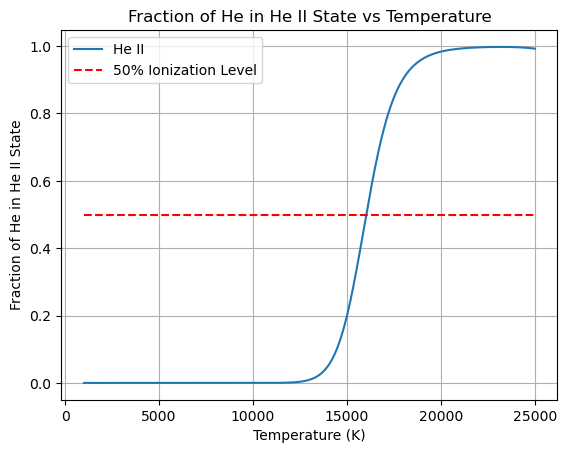

In [4]:
temprange = np.linspace(1000,25000,1000)
temp = temprange * u.K
charge1 = 1
charge2 = 2
ionization_energy = 24.6 * u.eV
n2_n1 = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)

charge1 = 2
charge2 = 1
ionization_energy = 54.4 * u.eV
n3_n2 = Saha_Equation(temp, electron_pressure, charge1, charge2, ionization_energy)

n2_ntotal = n2_n1 / (1 + n2_n1 + n2_n1*n3_n2)
n2_ntotal

plottingarray = [temprange, n2_ntotal]

plt.plot(plottingarray[0], plottingarray[1], label='He II')
plt.hlines(0.5, color='r', linestyle='--', label = '50% Ionization Level',xmin=np.min(temprange), xmax=np.max(temprange))
plt.title('Fraction of He in He II State vs Temperature')
plt.xlabel('Temperature (K)')
plt.ylabel('Fraction of He in He II State')
plt.grid()
plt.legend()
plt.show()

In [3]:
def Kepler1(L,mu,M,e,theta):
    """
    Calculate the radial distance r in a Keplerian orbit.

    Parameters:
    L (float): Angular momentum per unit mass.
    mu (float): Standard gravitational parameter (G*M).
    M (float): Mass of the central body.
    e (float): Eccentricity of the orbit.
    theta (float): True anomaly in radians.

    Returns:
    float: Radial distance r.
    """
    if L.unit != (u.m**2 / u.s):
        try:
            L.to(u.m**2 / u.s)
        except Exception:
            raise ValueError("L must have units of m^2/s")
    if mu.unit != (u.m**3 / u.s**2):
        try:
            mu.to(u.m**3 / u.s**2)
        except Exception:
            raise ValueError("mu must have units of m^3/s^2")
    if M.unit != u.kg:
        try: 
            M.to(u.kg)
        except Exception:
            raise ValueError("M must have units of kg")
    if not isinstance(e, (int, float)):
        raise ValueError("e must be a dimensionless number")
    if not isinstance(theta, (int, float)):
        raise ValueError("theta must be a dimensionless number in radians")

    r = (L**2 / mu) / (1 + e * np.cos(theta))
    return r

def Kepler2(L,mu):
    """
    Finds the area traced out per unit time in an orbit
    Parameters:
    L (float): Angular momentum per unit mass.
    mu (float): Standard gravitational parameter (G*M).
    
    Returns:
    float: Area traced out per unit time.
    """
    if L.unit != (u.m**2 / u.s):
        try:
            L.to(u.m**2 / u.s)
        except Exception:
            raise ValueError("L must have units of m^2/s")
    if mu.unit != (u.m**3 / u.s**2):
        try:
            mu.to(u.m**3 / u.s**2)
        except Exception:
            raise ValueError("mu must have units of m^3/s^2")
    return 1/2 * L / mu

def Kepler2Velocity(m1, m2, r, a):
    """
    Calculate the orbital velocity in a two-body system.

    Parameters:
    m1 (float): Mass of the first body.
    m2 (float): Mass of the second body.
    r (float): Distance between the two bodies.
    a (float): Semi-major axis of the orbit.

    Returns:
    float: Orbital velocity v.
    """
    if m1.unit != u.kg:
        try:
            m1.to(u.kg)
        except Exception:
            raise ValueError("m1 must have units of kg")
    if m2.unit != u.kg:
        try:
            m2.to(u.kg)
        except Exception:
            raise ValueError("m2 must have units of kg")
    if r.unit != u.m:
        try:
            r.to(u.m)
        except Exception:
            raise ValueError("r must have units of m")
    if a.unit != u.m:
        try:
            a.to(u.m)
        except Exception:
            raise ValueError("a must have units of m")
    G = const.G
    v = np.sqrt(G * (m1 + m2) * (2/r - 1/a))
    return v

def Kepler3(L, mu, e, T_expected):
    """
    Calculate the orbital period of a Keplerian orbit.

    Parameters:
    L (float): Angular momentum per unit mass.
    mu (float): Standard gravitational parameter (G*M).
    e (float): Eccentricity of the orbit.

    Returns:
    float: Orbital period T.
    """

    # if L.unit != (u.m**2 / u.s):
    #     try: L.to(u.m**2 / u.s)
    #     except Exception: raise ValueError("L must have units of m^2/s")
    # if mu.unit != (u.m**3 / u.s**2):
    #     try: mu.to(u.m**3 / u.s**2)
    #     except Exception: raise ValueError("mu must have units of m^3/s^2")
    # if e is not None:
    #     raise ValueError("e must be a dimensionless number")
    a = (L**2 / mu) / (1 - e**2)
    T_model = 2 * np.pi * np.sqrt(a**3 / mu)
    return T_model - T_expected

In [4]:
solve_quantity(Kepler2Velocity, 
               m1=5.972e24 * u.kg, 
               m2=7.348e22 * u.kg, 
               r=384400000 * u.m, 
               a=None, 
               x0=400000000 * u.m)

AttributeError: 'numpy.float64' object has no attribute 'unit'

In [ ]:
L = 2 * u.m**2 / u.s
mu = 3.986e14 * u.m**3 / u.s**2
T = 86400 * u.s
e = 0.69 * u.dimensionless_unscaled
solve_quantity(
    Kepler3, 
    L=L, 
    mu=None, 
    e=e, 
    T_expected=T,
    x0 = 1e14 * u.m**3 / u.s**2
)  # Example usage

/tmp/ipykernel_42338/213790941.py:64: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  sol = scipy.optimize.fsolve(g, x0)[0]


<Quantity 1.e+14 m3 / s2>

In [4]:
def virial_theorem(M,R):
    return -3/10 * M**2 * const.G / R

In [12]:
U_i = virial_theorem(M = 1.4 * u.M_sun, R = 1 * u.R_earth).to(u.J)
U_intermediate = virial_theorem(M = 1.4 * u.M_sun, R = 50 * u.km).to(u.J)
U_f = virial_theorem(M = 1.4 * u.M_sun, R = 12 * u.km).to(u.J)

In [36]:
del_u = U_intermediate - U_i
del_u
E_tot = 1.4 * u.M_sun * const.c**2
E_tot = E_tot.to(u.J)
E_f = E_tot + del_u
print(E_tot, E_f)

2.5019311362377908e+47 J 2.4711413356975917e+47 J


In [31]:
E_tot

<Quantity 2.50193114e+47 J>

In [5]:
### Method 1: Using only Virial Theoreom.

# Phase 1: Collapse from 1 Earth Radius to 50 km
M_i = 1.4 * u.M_sun
R_i = 1 * u.R_earth
R_f = 50 * u.km
U_i = virial_theorem(M = M_i, R = R_i).to(u.J)
E_tot_i = (1.4 * u.M_sun * const.c**2).to(u.J)
U_f = virial_theorem(M = M_i, R = R_f).to(u.J)
E_tot_f = E_tot_i - np.abs((U_f-U_i))
M_f = E_tot_f/const.c**2
print('final mass after first collapse ' + str(M_f.to(u.M_sun)))

# Phase 2: Collapse from 50 km to 12 km.
M_i = M_f
R_i = R_f
R_f = 12 * u.km
U_i = virial_theorem(M = M_i, R = R_i).to(u.J)
E_tot_i = (1.4 * u.M_sun * const.c**2).to(u.J)
U_f = virial_theorem(M = M_i, R = R_f).to(u.J)
E_tot_f = E_tot_i - np.abs((U_f-U_i))
M_f = E_tot_f/const.c**2
M_f.to(u.M_sun)
print('final mass after second collapse ' + str(M_f.to(u.M_sun)))


final mass after first collapse 1.3827710203003036 solMass
final mass after second collapse 1.3463556030574344 solMass


In [13]:
def solve(f, args):
    i = args.index(None)
    if args.count(None) != 1:
        raise ValueError("Only one argument can be None")
    return scipy.optimize.fsolve(lambda x: f(*args[:i], x, *args[i+1:]), 1)[0]

def virial_theorem_solveable(M,R,U):
    return (-3/10 * M**2 * const.G.value / R) - U

M = 1.4 * u.M_sun
R = 1 * u.R_earth
U = None

solve(virial_theorem_solveable, (M.value, R.value, U))

np.float64(-3.924488399999999e-11)

In [57]:
### Method 2: Using Virial theorem for initial collapse, then using free-fall timescale for second collapse.

# Phase 1: Collapse from 1 Earth Radius to 50 km.
M_i = 1.4 * u.M_sun
R_i = 1 * u.R_earth
R_f = 50 * u.km
U_i = virial_theorem(M = M_i, R = R_i).to(u.J)
E_tot_i = (1.4 * u.M_sun * const.c**2).to(u.J)
U_f = virial_theorem(M = M_i, R = R_f).to(u.J)
E_tot_f = E_tot_i - np.abs((U_f-U_i))
M_f = E_tot_f/const.c**2
M_f.to(u.M_sun)

# Phase 2: Collapse from 50 km to 12 km.
M_i = M_f
R_i = R_f 
R_f = 12 * u.km
rho = M_i / ( 4/3 * np.pi * R_i**3)
print(rho.to(u.kg/u.m**3))
T_ff = ((3 * np.pi ) / 32) * (1 / (const.G * rho) )**0.5
T_ff.to(u.s)

5251187882436432.0 kg / m3


<Quantity 0.0004975 s>